In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


##### EDA

In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
df["sex"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [12]:
df["region"].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [13]:
df["smoker"].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [14]:
numeric_columns = ["age","bmi","children","charges"]
numeric_columns

['age', 'bmi', 'children', 'charges']

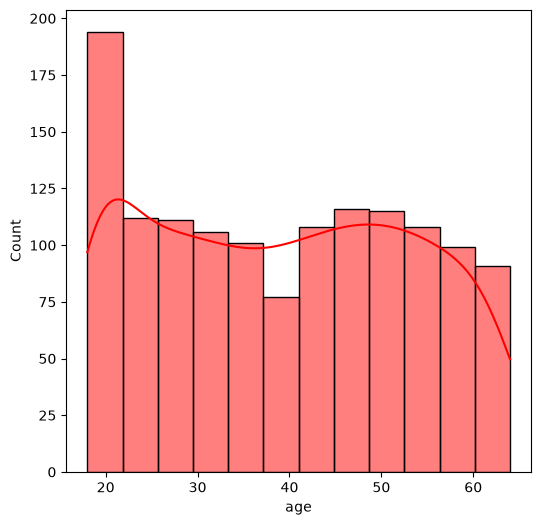

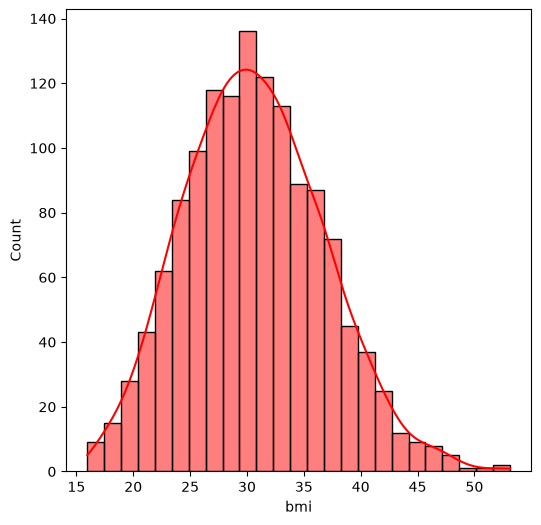

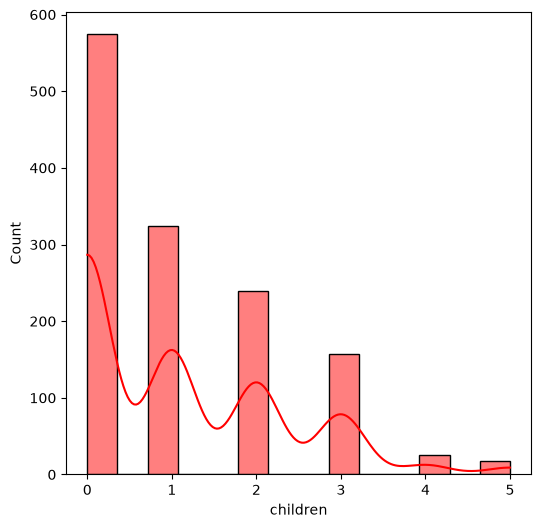

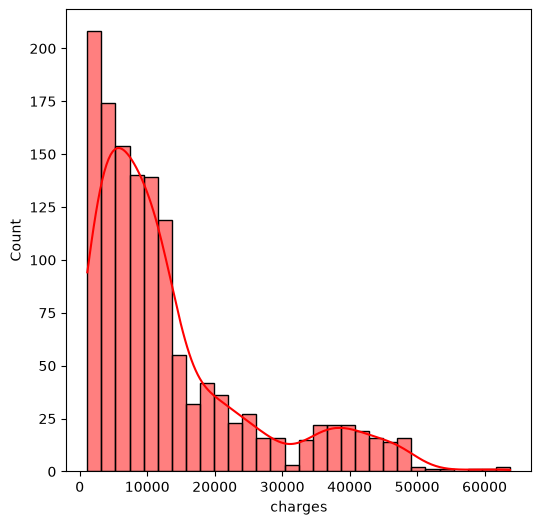

In [15]:
for col in numeric_columns :
   fig = plt.figure(figsize=(6,6))
   sns.histplot(df[col],kde=True,color="red")



<Axes: xlabel='age', ylabel='count'>

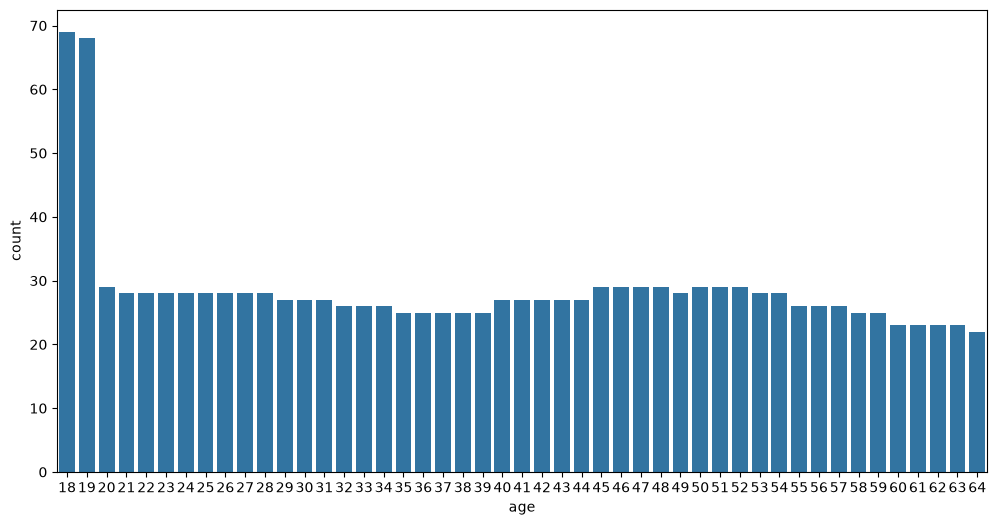

In [16]:
fig = plt.figure(figsize = (12,6))
sns.countplot(data = df,x = "age")

<Axes: xlabel='children', ylabel='count'>

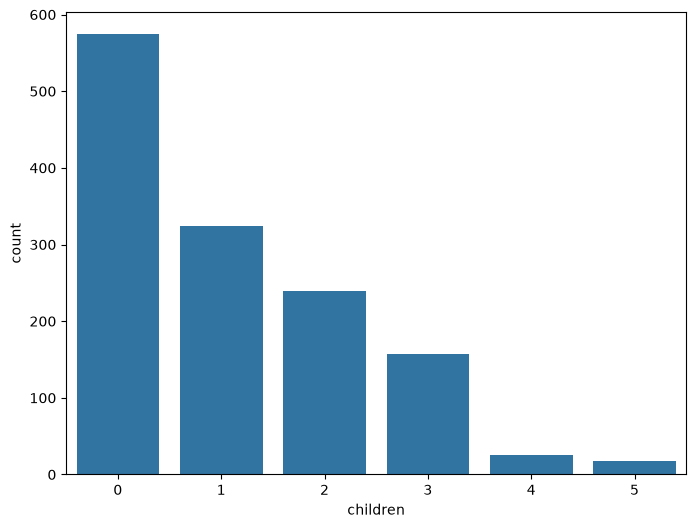

In [17]:
fig = plt.figure(figsize = (8,6))
sns.countplot(data = df,x = "children")

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='sex', ylabel='count'>

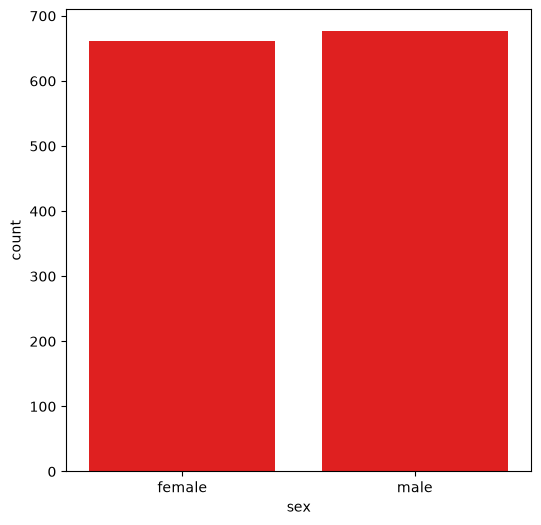

In [19]:
fig = plt.figure(figsize = (6,6))
sns.countplot(data = df,x = "sex",color = "red")

<Axes: xlabel='sex', ylabel='count'>

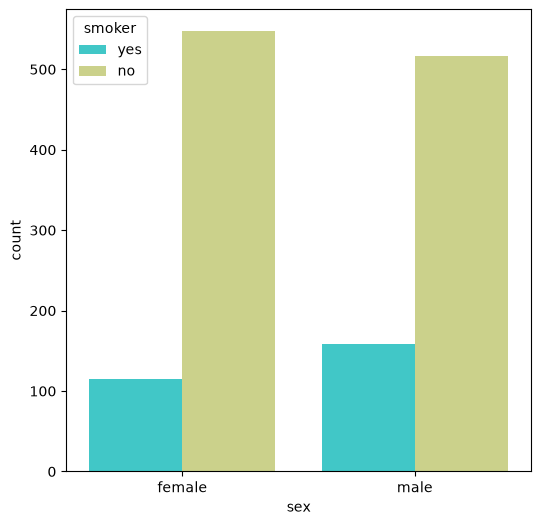

In [20]:
fig = plt.figure(figsize = (6,6))
sns.countplot(data = df,x = "sex",palette="rainbow",hue ="smoker")

<Axes: xlabel='charges', ylabel='Count'>

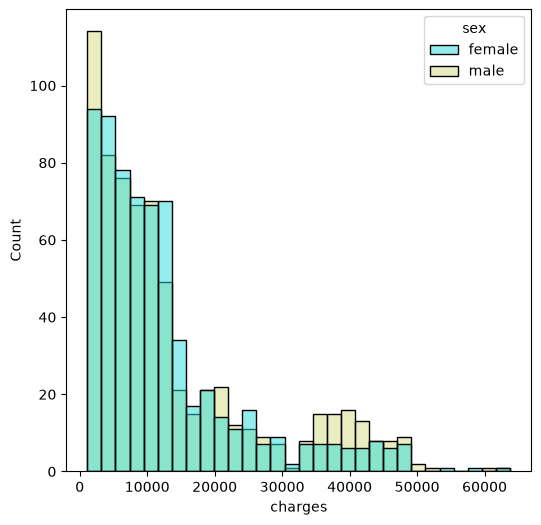

In [21]:
fig = plt.figure(figsize = (6,6))
sns.histplot(data = df,x = "charges",hue="sex",palette="rainbow")

<Axes: xlabel='smoker', ylabel='count'>

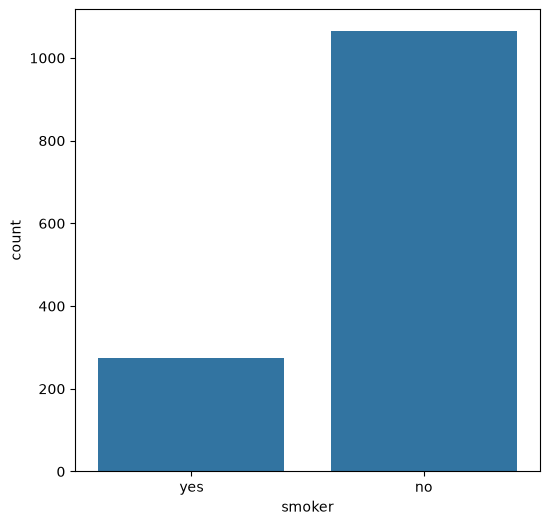

In [22]:
fig = plt.figure(figsize = (6,6))
sns.countplot(data = df,x = "smoker")

In [23]:
numeric_columns

['age', 'bmi', 'children', 'charges']

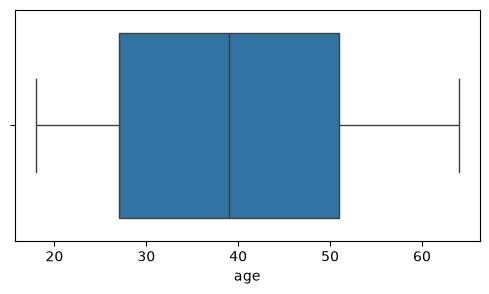

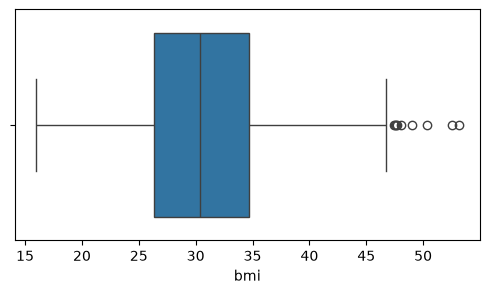

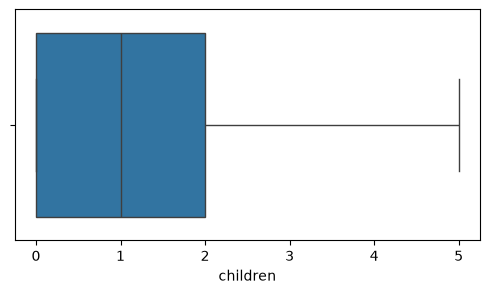

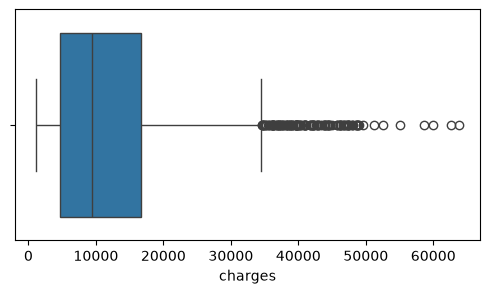

In [24]:
for col in numeric_columns :
   fig = plt.figure(figsize=(6,3))
   sns.boxplot(x = df[col])

<Axes: xlabel='charges', ylabel='smoker'>

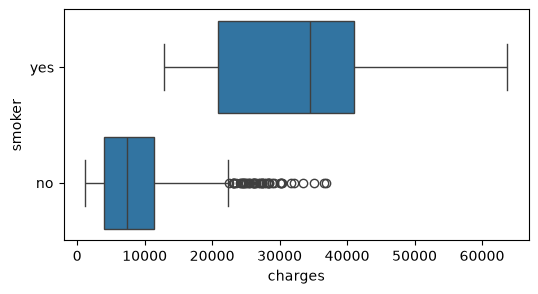

In [25]:
fig = plt.figure(figsize=(6,3))
sns.boxplot(y = df["smoker"],x = df["charges"])

<Axes: >

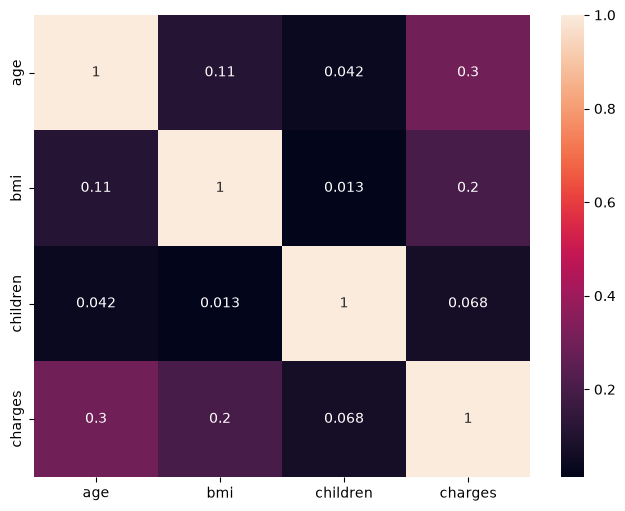

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

##### Data Cleaning & Preprocessing

In [27]:
df_cleaned = df
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [28]:
df_cleaned.shape

(1338, 7)

In [29]:
df_cleaned.duplicated().sum()

np.int64(1)

In [30]:
df_cleaned.drop_duplicates(inplace=True)

In [31]:
df.shape

(1337, 7)

In [32]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [33]:
df_cleaned["sex"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [34]:
df_cleaned["sex"] = df_cleaned["sex"].map({"male" : 0,"female" : 1})
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [35]:
df_cleaned["smoker"] = df_cleaned["smoker"].map({"no" : 0,"yes" : 1})
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [36]:
df_cleaned.rename(columns = {"sex" : "is_female","smoker" : "is_smoker"},inplace=True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [37]:
df_cleaned.region.unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [38]:
df_cleaned['southwest'] = df_cleaned["region"] == "southwest"
df_cleaned['southeast'] = df_cleaned["region"] == "southeast"
df_cleaned['northwest'] = df_cleaned["region"] == "northwest"
df_cleaned['northeast'] = df_cleaned["region"] == "northeast"
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges,southwest,southeast,northwest,northeast
0,19,1,27.900,0,1,southwest,16884.92400,True,False,False,False
1,18,0,33.770,1,0,southeast,1725.55230,False,True,False,False
2,28,0,33.000,3,0,southeast,4449.46200,False,True,False,False
3,33,0,22.705,0,0,northwest,21984.47061,False,False,True,False
4,32,0,28.880,0,0,northwest,3866.85520,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830,False,False,True,False
1334,18,1,31.920,0,0,northeast,2205.98080,False,False,False,True
1335,18,1,36.850,0,0,southeast,1629.83350,False,True,False,False
1336,21,1,25.800,0,0,southwest,2007.94500,True,False,False,False


In [39]:
df_cleaned.drop(labels= ["region"],inplace=True,axis =1 )
df_cleaned = df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,southwest,southeast,northwest,northeast
0,19,1,27,0,1,16884,1,0,0,0
1,18,0,33,1,0,1725,0,1,0,0
2,28,0,33,3,0,4449,0,1,0,0
3,33,0,22,0,0,21984,0,0,1,0
4,32,0,28,0,0,3866,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,0,1,0
1334,18,1,31,0,0,2205,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0
1336,21,1,25,0,0,2007,1,0,0,0


##### Feature Engineering & Extraction

<Axes: xlabel='bmi', ylabel='Count'>

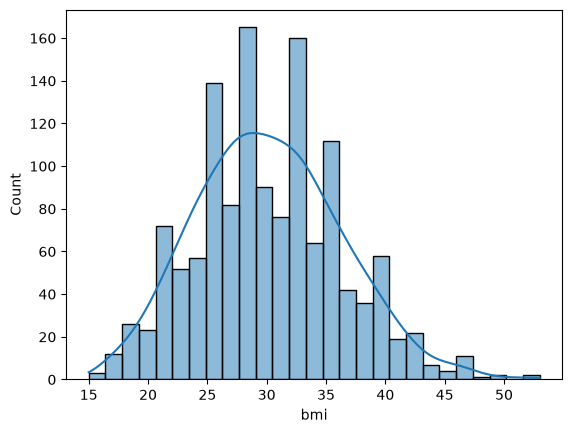

In [40]:
sns.histplot(df_cleaned["bmi"],kde=True)

In [41]:
df_cleaned["bmi_category"] = pd.cut(
    df_cleaned["bmi"],
    bins = [0,18.5,24.9,29.9,float("inf")],
    labels=["underweight","Normal","overweight","obese"]
)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,southwest,southeast,northwest,northeast,bmi_category
0,19,1,27,0,1,16884,1,0,0,0,overweight
1,18,0,33,1,0,1725,0,1,0,0,obese
2,28,0,33,3,0,4449,0,1,0,0,obese
3,33,0,22,0,0,21984,0,0,1,0,Normal
4,32,0,28,0,0,3866,0,0,1,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,0,1,0,obese
1334,18,1,31,0,0,2205,0,0,0,1,obese
1335,18,1,36,0,0,1629,0,1,0,0,obese
1336,21,1,25,0,0,2007,1,0,0,0,overweight


In [42]:
df_cleaned = pd.get_dummies(data = df_cleaned,columns=["bmi_category"])


In [43]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,southwest,southeast,northwest,northeast,bmi_category_underweight,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,1,0,0,0,False,False,True,False
1,18,0,33,1,0,1725,0,1,0,0,False,False,False,True
2,28,0,33,3,0,4449,0,1,0,0,False,False,False,True
3,33,0,22,0,0,21984,0,0,1,0,False,True,False,False
4,32,0,28,0,0,3866,0,0,1,0,False,False,True,False


In [44]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,southwest,southeast,northwest,northeast,bmi_category_underweight,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,1,0,0,0,0,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,0,0,1
3,33,0,22,0,0,21984,0,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,0,0,1,0,0,0,1,0


In [45]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'southwest', 'southeast', 'northwest', 'northeast',
       'bmi_category_underweight', 'bmi_category_Normal',
       'bmi_category_overweight', 'bmi_category_obese'],
      dtype='str')

In [46]:
from sklearn.preprocessing import StandardScaler
cols = ["age","bmi","children"]
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [47]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,southwest,southeast,northwest,northeast,bmi_category_underweight,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,1,0,0,0,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0,1,0,0,0,1,0


In [48]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'southwest', 'southeast', 'northwest', 'northeast',
       'bmi_category_underweight', 'bmi_category_Normal',
       'bmi_category_overweight', 'bmi_category_obese'],
      dtype='str')

In [49]:
from scipy.stats import pearsonr

# -----------------------------
# Pearson Co-relation 
# -----------------------------

selected_features = ['age', 'is_female', 'bmi', 'children', 'is_smoker', 
       'southwest', 'southeast', 'northwest', 'northeast',
       'bmi_category_underweight', 'bmi_category_Normal',
       'bmi_category_overweight', 'bmi_category_obese']

corelations = {
    feature : pearsonr(df_cleaned[feature],df_cleaned["charges"])[0]
    for feature in selected_features
}

corelations_df = pd.DataFrame(data = list(corelations.items()),columns = ["Features","pearson corelation with charges"])
corelations_df




,Features,pearson corelation with charges
0,age,0.298309
1,is_female,-0.058046
2,bmi,0.196236
3,children,0.067390
4,is_smoker,0.787234
5,southwest,-0.043637
6,southeast,0.073577
7,northwest,-0.038695
8,northeast,0.005946
9,bmi_category_underweight,-0.050599


In [50]:
corelations_df.sort_values(by = "pearson corelation with charges",ascending=False)

,Features,pearson corelation with charges
4,is_smoker,0.787234
0,age,0.298309
12,bmi_category_obese,0.200348
2,bmi,0.196236
6,southeast,0.073577
3,children,0.067390
8,northeast,0.005946
7,northwest,-0.038695
5,southwest,-0.043637
9,bmi_category_underweight,-0.050599


In [51]:
from scipy.stats import chi2_contingency

cat_features = ['is_female', 'is_smoker', 
       'southwest', 'southeast', 'northwest', 'northeast',
       'bmi_category_underweight', 'bmi_category_Normal',
       'bmi_category_overweight', 'bmi_category_obese','children']

In [52]:
alpha = 0.05

In [53]:
df_cleaned["charges_bin"] = pd.qcut(
    df_cleaned["charges"],
    q=4,
    labels=False
)

df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,southwest,southeast,northwest,northeast,bmi_category_underweight,bmi_category_Normal,bmi_category_overweight,bmi_category_obese,charges_bin
0,-1.440418,1,-0.517949,-0.909234,1,16884,1,0,0,0,0,0,1,0,3
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,0,0,1,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,0,0,1,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0,1,0,0,1,0,0,3
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0,1,0,0,0,1,0,0


In [54]:
chi2_res = {}

for feature in cat_features :
    chi2_stat,p_value,_,_ = chi2_contingency(pd.crosstab(df_cleaned[feature],df_cleaned["charges_bin"]))

    decision = None
    if p_value < alpha :
        decision = "Reject Null Keep Feature"
    else :
        decision = "Accept Null drop Feature"

    chi2_res[feature] = {
        "chi2_stat" : chi2_stat,
        "p_value" : p_value,
        "decision" : decision
    }

chi2_res

{'is_female': {'chi2_stat': np.float64(10.258784131896034),
  'p_value': np.float64(0.016489740254825688),
  'decision': 'Reject Null Keep Feature'},
 'is_smoker': {'chi2_stat': np.float64(848.2191784691495),
  'p_value': np.float64(1.5074776554531109e-183),
  'decision': 'Reject Null Keep Feature'},
 'southwest': {'chi2_stat': np.float64(5.091893034250699),
  'p_value': np.float64(0.16519063312163632),
  'decision': 'Accept Null drop Feature'},
 'southeast': {'chi2_stat': np.float64(15.998167448977355),
  'p_value': np.float64(0.0011349657141180658),
  'decision': 'Reject Null Keep Feature'},
 'northwest': {'chi2_stat': np.float64(1.1342403613235656),
  'p_value': np.float64(0.76881540917986),
  'decision': 'Accept Null drop Feature'},
 'northeast': {'chi2_stat': np.float64(6.438442307376374),
  'p_value': np.float64(0.09212205767134653),
  'decision': 'Accept Null drop Feature'},
 'bmi_category_underweight': {'chi2_stat': np.float64(3.3740297227214078),
  'p_value': np.float64(0.3374

In [55]:
# Method 1 to make separate columns dataframe with 3 features stat_val pval and decision 
chi2_df = pd.DataFrame(data = list(chi2_res.items()),columns=["Features","chi2 relation with charges bin"])
chi2_df

,Features,chi2 relation with charges bin
0,is_female,"{'chi2_stat': 10.258784131896034, 'p_value': 0..."
1,is_smoker,"{'chi2_stat': 848.2191784691495, 'p_value': 1...."
2,southwest,"{'chi2_stat': 5.091893034250699, 'p_value': 0...."
3,southeast,"{'chi2_stat': 15.998167448977355, 'p_value': 0..."
4,northwest,"{'chi2_stat': 1.1342403613235656, 'p_value': 0..."
5,northeast,"{'chi2_stat': 6.438442307376374, 'p_value': 0...."
6,bmi_category_underweight,"{'chi2_stat': 3.3740297227214078, 'p_value': 0..."
7,bmi_category_Normal,"{'chi2_stat': 3.7080882993067794, 'p_value': 0..."
8,bmi_category_overweight,"{'chi2_stat': 4.2514897526301425, 'p_value': 0..."
9,bmi_category_obese,"{'chi2_stat': 8.515710780987105, 'p_value': 0...."


In [56]:
chi2_df["chi2 relation with charges bin"]

0     {'chi2_stat': 10.258784131896034, 'p_value': 0...
1     {'chi2_stat': 848.2191784691495, 'p_value': 1....
2     {'chi2_stat': 5.091893034250699, 'p_value': 0....
3     {'chi2_stat': 15.998167448977355, 'p_value': 0...
4     {'chi2_stat': 1.1342403613235656, 'p_value': 0...
5     {'chi2_stat': 6.438442307376374, 'p_value': 0....
6     {'chi2_stat': 3.3740297227214078, 'p_value': 0...
7     {'chi2_stat': 3.7080882993067794, 'p_value': 0...
8     {'chi2_stat': 4.2514897526301425, 'p_value': 0...
9     {'chi2_stat': 8.515710780987105, 'p_value': 0....
10    {'chi2_stat': 138.65931339918984, 'p_value': 4...
Name: chi2 relation with charges bin, dtype: object

In [57]:
chi2_df[["chi2_stat", "p_value", "decision"]] = (
    chi2_df["chi2 relation with charges bin"]
    .apply(pd.Series)
)

chi2_df

,Features,chi2 relation with charges bin,chi2_stat,p_value,decision
0,is_female,"{'chi2_stat': 10.258784131896034, 'p_value': 0...",10.258784,1.648974e-02,Reject Null Keep Feature
1,is_smoker,"{'chi2_stat': 848.2191784691495, 'p_value': 1....",848.219178,1.507478e-183,Reject Null Keep Feature
2,southwest,"{'chi2_stat': 5.091893034250699, 'p_value': 0....",5.091893,1.651906e-01,Accept Null drop Feature
3,southeast,"{'chi2_stat': 15.998167448977355, 'p_value': 0...",15.998167,1.134966e-03,Reject Null Keep Feature
4,northwest,"{'chi2_stat': 1.1342403613235656, 'p_value': 0...",1.134240,7.688154e-01,Accept Null drop Feature
5,northeast,"{'chi2_stat': 6.438442307376374, 'p_value': 0....",6.438442,9.212206e-02,Accept Null drop Feature
6,bmi_category_underweight,"{'chi2_stat': 3.3740297227214078, 'p_value': 0...",3.374030,3.374713e-01,Accept Null drop Feature
7,bmi_category_Normal,"{'chi2_stat': 3.7080882993067794, 'p_value': 0...",3.708088,2.947595e-01,Accept Null drop Feature
8,bmi_category_overweight,"{'chi2_stat': 4.2514897526301425, 'p_value': 0...",4.251490,2.355571e-01,Accept Null drop Feature
9,bmi_category_obese,"{'chi2_stat': 8.515710780987105, 'p_value': 0....",8.515711,3.647336e-02,Reject Null Keep Feature


In [58]:
chi2_df.drop(labels="chi2 relation with charges bin",axis = 1,inplace= True)
chi2_df

,Features,chi2_stat,p_value,decision
0,is_female,10.258784,1.648974e-02,Reject Null Keep Feature
1,is_smoker,848.219178,1.507478e-183,Reject Null Keep Feature
2,southwest,5.091893,1.651906e-01,Accept Null drop Feature
3,southeast,15.998167,1.134966e-03,Reject Null Keep Feature
4,northwest,1.134240,7.688154e-01,Accept Null drop Feature
5,northeast,6.438442,9.212206e-02,Accept Null drop Feature
6,bmi_category_underweight,3.374030,3.374713e-01,Accept Null drop Feature
7,bmi_category_Normal,3.708088,2.947595e-01,Accept Null drop Feature
8,bmi_category_overweight,4.251490,2.355571e-01,Accept Null drop Feature
9,bmi_category_obese,8.515711,3.647336e-02,Reject Null Keep Feature


In [59]:
# Method 2 to make separate columns dataframe with 3 features stat_val pval and decision 
chi2_df = pd.DataFrame(data = chi2_res)
chi2_df

,is_female,is_smoker,southwest,southeast,northwest,northeast,bmi_category_underweight,bmi_category_Normal,bmi_category_overweight,bmi_category_obese,children
chi2_stat,10.258784,848.219178,5.091893,15.998167,1.13424,6.438442,3.37403,3.708088,4.25149,8.515711,138.659313
p_value,0.01649,0.0,0.165191,0.001135,0.768815,0.092122,0.337471,0.29476,0.235557,0.036473,0.0
decision,Reject Null Keep Feature,Reject Null Keep Feature,Accept Null drop Feature,Reject Null Keep Feature,Accept Null drop Feature,Accept Null drop Feature,Accept Null drop Feature,Accept Null drop Feature,Accept Null drop Feature,Reject Null Keep Feature,Reject Null Keep Feature


In [60]:
chi2_df = chi2_df.T
chi2_df

,chi2_stat,p_value,decision
is_female,10.258784,0.01649,Reject Null Keep Feature
is_smoker,848.219178,0.0,Reject Null Keep Feature
southwest,5.091893,0.165191,Accept Null drop Feature
southeast,15.998167,0.001135,Reject Null Keep Feature
northwest,1.13424,0.768815,Accept Null drop Feature
northeast,6.438442,0.092122,Accept Null drop Feature
bmi_category_underweight,3.37403,0.337471,Accept Null drop Feature
bmi_category_Normal,3.708088,0.29476,Accept Null drop Feature
bmi_category_overweight,4.25149,0.235557,Accept Null drop Feature
bmi_category_obese,8.515711,0.036473,Reject Null Keep Feature


In [61]:
chi2_df = chi2_df.sort_values(by = "p_value",ascending= True)
chi2_df

,chi2_stat,p_value,decision
is_smoker,848.219178,0.0,Reject Null Keep Feature
children,138.659313,0.0,Reject Null Keep Feature
southeast,15.998167,0.001135,Reject Null Keep Feature
is_female,10.258784,0.01649,Reject Null Keep Feature
bmi_category_obese,8.515711,0.036473,Reject Null Keep Feature
northeast,6.438442,0.092122,Accept Null drop Feature
southwest,5.091893,0.165191,Accept Null drop Feature
bmi_category_overweight,4.25149,0.235557,Accept Null drop Feature
bmi_category_Normal,3.708088,0.29476,Accept Null drop Feature
bmi_category_underweight,3.37403,0.337471,Accept Null drop Feature


In [62]:
corelations_df.sort_values(by = "pearson corelation with charges",ascending=False)

,Features,pearson corelation with charges
4,is_smoker,0.787234
0,age,0.298309
12,bmi_category_obese,0.200348
2,bmi,0.196236
6,southeast,0.073577
3,children,0.067390
8,northeast,0.005946
7,northwest,-0.038695
5,southwest,-0.043637
9,bmi_category_underweight,-0.050599


In [63]:
final_df = df_cleaned[["is_smoker","bmi_category_obese","southeast","is_female","age","bmi","children","charges"]]

In [64]:
final_df

,is_smoker,bmi_category_obese,southeast,is_female,age,bmi,children,charges
0,1,0,0,1,-1.440418,-0.517949,-0.909234,16884
1,0,1,1,0,-1.511647,0.462463,-0.079442,1725
2,0,1,1,0,-0.799350,0.462463,1.580143,4449
3,0,0,0,0,-0.443201,-1.334960,-0.909234,21984
4,0,0,0,0,-0.514431,-0.354547,-0.909234,3866
...,...,...,...,...,...,...,...,...
1333,0,1,0,0,0.767704,-0.027743,1.580143,10600
1334,0,1,0,1,-1.511647,0.135659,-0.909234,2205
1335,0,1,1,1,-1.511647,0.952670,-0.909234,1629
1336,0,0,0,1,-1.297958,-0.844753,-0.909234,2007


##### Create Model

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X = final_df.drop("charges",axis = 1)
Y = final_df["charges"]

In [67]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.20,random_state=42)

In [68]:
from sklearn.linear_model import LinearRegression

In [69]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[23080.28, 3285.92, -264.14,..., 3489.11, 565.67, 645.81]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['is_smoker','bmi_category_obese','southeast',...,'age','bmi','children']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6769
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


##### Test & Model Evaluation

In [70]:
y_pred = model.predict(x_test)
y_pred

array([ 7856.41808069,  5379.07145062, 14613.47489419, 32465.93193508,
        8955.35729283, 13336.43605749, 30199.07309038,  1403.40503994,
       11196.90873514, 10018.65838301, 10818.71629044, 32144.43533014,
       31550.26059902, 16230.55597963, 10285.99989714,  8488.6608457 ,
        5487.64476113, 32465.09672212,  3304.46601962,  3877.00422671,
        4760.01023433, 28796.29743032, 13870.98195763, 29541.88243902,
       31520.15678042,  6344.44675222, 35026.69683204, 37880.73853364,
       12490.06211178, 14238.95332785,  7573.09915473, 13049.08020135,
         516.21534048, 11339.74207305, 37584.28749479, 13356.84393437,
        3706.96614326,  4537.12786929, 31481.80485676,  8009.55465514,
        6075.79442888, 30404.81913857, 35276.56346051, 13099.59189682,
        7977.69705664,  2987.00634487,  5174.11237148,  7620.54073087,
        3522.89053725, 10388.99625751,  7820.00530896, 10505.68054495,
       30331.09138384,  4687.62077185, 11676.0149257 , 11446.77536361,
      

In [71]:
y_test

900      8688
1064     5708
1256    11436
298     38746
237      4463
        ...  
534     13831
542     13887
760      3925
1284    47403
1285     8534
Name: charges, Length: 268, dtype: int64

In [72]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
r2

0.8040712413347116

In [73]:
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1 -((1 - r2) * (n-1)/ (n-p-1))
adjusted_r2

0.7987962362937231